In [1]:
# load Packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tableone import TableOne

# machine learning
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.model_selection import StratifiedKFold, GridSearchCV, train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_curve, 
    auc, 
    confusion_matrix, 
    classification_report,
    precision_recall_curve,
    average_precision_score
)

In [2]:
# =================
# HELPER FUNCTIONS
# =================

def plot_outcome_crosstab(df, feature, title, xlabel, xtick_labels, ylim=(0, 80)):
    """P(Glycemic Control | Feature); Plot outcome of cross-table between two features"""

    # 'index': display percentage as total of row values.
    distrib = pd.crosstab(df[feature], df['glycemic_control'], normalize='index').sort_index() * 100
    ax = distrib.plot(
        kind='bar',
        title=title,
        ylabel='Percentage of Patients (%)',
        xlabel=xlabel,
        ylim=ylim,
        width=0.8
    )
    ax.bar_label(ax.containers[0], fmt='%.1f%%')
    ax.bar_label(ax.containers[1], fmt='%.1f%%')
    plt.legend(['A1C ≥ 7%','A1C < 7%'], title='Treatment Outcome')
    plt.xticks(np.arange(len(xtick_labels)), xtick_labels, rotation=0)
    plt.show()

def plot_roc_curve(y_true, y_proba, ax=None, label=None):
    """Plot ROC curve on given axis"""
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    roc_auc = auc(fpr, tpr)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    ax.plot(fpr, tpr, label=f'{label} (AUC={roc_auc:.2f})')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title('ROC Curve')
    ax.legend()
    ax.grid(True)

    return roc_auc

def plot_pr_curve(y_true, y_proba, ax=None, label=None):
    """Plot Precision-Recall curve on given axis"""
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    ax.plot(recall, precision, label=f'{label} (AP={ap:.2f})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title('Precision-Recall Curve')
    ax.legend()
    ax.grid(True)

    return ap

def plot_confmat(y_true, y_pred, model_names, ax=None, name=None):
    cf_matrix = confusion_matrix(y_true, y_pred)
    cf_matrix_norm = confusion_matrix(y_true, y_pred, normalize='all')

    # create labels
    labels = np.array([
        [f'True Negative\n {cf_matrix[0,0]} ({cf_matrix_norm[0,0]*100:.1f}%)',
        f'False Positive\n {cf_matrix[0,1]} ({cf_matrix_norm[0,1]*100:.1f}%)'],
        [f'False Negative\n {cf_matrix[1,0]} ({cf_matrix_norm[1,0]*100:.1f}%)',
        f'True Positive\n{cf_matrix[1,1]} ({cf_matrix_norm[1,1]*100:.1f}%)']
    ])

    if ax is None:
        _, ax = plt.subplots(figsize=(6, 5))

    # plot confusion matrix
    sns.heatmap(
        cf_matrix, 
        annot=labels, 
        fmt='', 
        cmap='Blues', 
        cbar=False, 
        square=True, 
        ax=ax
    )
    ax.set_title(f"{model_names[name]}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticklabels(["Negative", "Positive"])
    ax.set_yticklabels(["Negative", "Positive"])

def print_classification_metrics(results_dict, y_true, model_names):
    """
    Print comprehensive classification metrics for all models

    Parameters
    ----------
    results_dict : dict
        {name: {'y_pred': ...}}
    """

    for name, preds in results_dict.items():
        print(f'\n{'='*60}')
        print(f"{model_names[name]}")
        print(f'{'='*60}')

        # classification report
        print(classification_report(y_true, preds['y_pred'], digits=2))

        # ROC-AUC
        fpr, tpr, _ = roc_curve(y_true, preds['y_proba'])
        print(f'ROC-AUC: {auc(fpr, tpr):.2f}')

        # PR-AP
        print(f'PR-AP: {average_precision_score(y_true, preds['y_proba']):.2f}')

def class_metrics_table(results_dict, y_true, model_names):
    """
    Create a table from class-1 metrics.

    Parameters
    ----------
    results_dict : dict
        {name: {'y_pred': ...}}
    """
    results = []
    for name in results_dict:

        report = classification_report(y_true, results_dict[name]['y_pred'], output_dict=True)

        # core metrics
        acc = report['accuracy']
        prec = report['1']['precision']
        rec = report['1']['recall']
        f1 = report['1']['f1-score']

        # ROC-AUC
        fpr, tpr, _ = roc_curve(y_true, results_dict[name]['y_proba'])
        auc_val = auc(fpr, tpr)

        # PR-AP
        ap = average_precision_score(y_true, results_dict[name]['y_proba'])

        # create table of metrics
        results.append({
            'Model': model_names[name],
            'ROC-AUC': f'{auc_val:.2f}',
            'PR-AP': f'{ap:.2f}',
            'Accuracy': f'{acc:.2f}',
            'Precision': f'{prec:.2f}',
            'Recall': f'{rec:.2f}',
            'F1': f'{f1:.2f}',
        })

    return pd.DataFrame(results).set_index('Model')

In [3]:
df = pd.read_csv('mdclone_data.csv')
df.head()

,sex assigned at birth,race - primary,date of birth,ethnicity,cohort reference event-age at event,cohort reference event-medication,kidney_disease_months,kidney_disease_condition,ketoacidosis_months,hyperglycemia_months,...,bmi_condition,bmi_months,metformin_months,insulin_use_months,baseline_hba1c_result,baseline_hba1c_months,post_hba1c_result_average,post_hba1c_result_std,hypoglycemic_meds_months,hypertension_months
0,Female,Black or African-American,1941,"Not Hispanic, Latino/a, or Spanish origin",82.110851,A10BJ02,-1.772820,E11.22,NaN,NaN,...,NaN,NaN,NaN,-0.837439,NaN,NaN,NaN,NaN,NaN,NaN
1,Female,Black or African-American,1968,"Not Hispanic, Latino/a, or Spanish origin",58.140828,A10BJ02,-13.348020,E11.22,NaN,-1.654529,...,NaN,NaN,NaN,NaN,8.0,-1.517613,NaN,NaN,-8.969387,-0.768217
2,Female,Black or African-American,1968,"Not Hispanic, Latino/a, or Spanish origin",57.668318,A10BJ02,0.159476,E11.22,NaN,NaN,...,NaN,NaN,NaN,-0.000204,NaN,NaN,NaN,NaN,NaN,NaN
3,Female,Black or African-American,1946,"Not Hispanic, Latino/a, or Spanish origin",77.808458,A10BJ02,-39.720786,E11.22,NaN,-35.768810,...,NaN,NaN,NaN,-23.351669,NaN,-2.233310,4.85,0.000000,NaN,-1.427541
4,Female,Black or African-American,1955,"Not Hispanic, Latino/a, or Spanish origin",63.682616,A10BJ02,-14.402258,E11.22,-41.225503,NaN,...,NaN,NaN,NaN,NaN,9.3,-0.069428,7.90,0.260945,NaN,NaN


In [4]:
df.shape

(15777, 25)

In [5]:
# ======================
# EXAMINE MISSING VALUES
# ======================

df.isnull().sum() * 100 / len(df)

sex assigned at birth                   0.000000
race - primary                          0.044368
date of birth                           0.000000
ethnicity                               0.044368
cohort reference event-age at event     0.000000
cohort reference event-medication       0.000000
kidney_disease_months                  90.403752
kidney_disease_condition               90.365722
ketoacidosis_months                    97.908348
hyperglycemia_months                   77.454522
other_specified_months                 90.422767
circulatory_complications_months       97.141408
hypoglycemia_months                    97.927363
unspecified_complications_months       88.679724
no_complications_months                39.335742
bmi_condition                          84.420359
bmi_months                             86.664131
metformin_months                       63.833428
insulin_use_months                     87.361349
baseline_hba1c_result                  62.400963
baseline_hba1c_month

# Data Cleaning & Feature Engineering

In [6]:
# drop unused columns
df = df.drop(columns=[
    'date of birth',
    'kidney_disease_condition',
    'no_complications_months',
    'bmi_condition',
    'bmi_months',
    'baseline_hba1c_months',
    'post_hba1c_result_std',
    'ethnicity'
]) 

# shorten column names
df = df.rename(columns={
    'sex assigned at birth':'sex',
    'race - primary':'race',
    'cohort reference event-age at event':'age',
    'cohort reference event-medication':'glp_medication',
    'kidney_disease_months':'has_kidney_disease',
    'ketoacidosis_months':'has_ketoacidosis',
    'hyperglycemia_months':'has_hyperglycemia',
    'other_specified_months':'has_other_specified',
    'circulatory_complications_months':'has_circulatory',
    'unspecified_complications_months':'has_unspecified',
    'metformin_months':'metformin_use',
    'insulin_use_months':'insulin_use',
    'hypertension_months':'has_hypertension'
})

# change sex labels to lowercase
df['sex'] = df['sex'].str.lower() 

# change medication ATC code to generic name  
df['glp_medication'] = df['glp_medication'].map({
    'A10BJ06':'semaglutide',
    'A10BJ02':'liraglutide',
    'A10BX16':'tirzepatide'
})

# drop patient not undergoing GLP-1 RA therapy (1 record)
df = df.dropna(subset=['glp_medication']) 

# simplify race names
df['race']=df['race'].replace({
    'Black or African-American': 'black',
    'White': 'white',
    'Asian/Mideast Indian': 'other',
    'Asian Indian': 'other',
    'Other Asian': 'other',
    'Filipino': 'other',
    'American Indian or Alaska Native': 'other',
    'Other Pacific Islander': 'other',
    'More than one Race':'other',
    'None of the above':'other',
    'Unknown or Patient unable to respond': 'unknown',
    'censored':'unknown',
    'Patient declines to respond':'unknown'
})

df.columns.tolist()

['sex',
 'race',
 'age',
 'glp_medication',
 'has_kidney_disease',
 'has_ketoacidosis',
 'has_hyperglycemia',
 'has_other_specified',
 'has_circulatory',
 'hypoglycemia_months',
 'has_unspecified',
 'metformin_use',
 'insulin_use',
 'baseline_hba1c_result',
 'post_hba1c_result_average',
 'hypoglycemic_meds_months',
 'has_hypertension']

In [7]:
# ======================================================================================================
# CATEGORIZE COMPLICATIONS AND COCURRENT MEDICATIONS AS PREVALENCE RATHER THEN EVENT-RELATED DIAGNOSIS
# ======================================================================================================

concomitants = ['insulin_use', 'metformin_use']

complications = [
    'has_kidney_disease',
    'has_ketoacidosis',
    'has_hyperglycemia',
    'has_other_specified',
    'has_circulatory',
    'has_unspecified',
    'has_hypertension',
]

# 1: diagnosis documented; 0: absence of dianogsis (i.e. event not observed in patient)
df[complications + concomitants] = df[complications + concomitants].notna().astype(int)

In [8]:
# =========================================================
# SELECT RECORDS OF PATIENTS THAT SATISFY COHORT CRITERTIA  
# =========================================================

# select patients that are adults
df = df[df['age'] >= 18] 

# select patients with uncontrolled diabetes (HBA1C >= 7%) or had no baseline recorded
df = df[(df['baseline_hba1c_result'] >= 7) | df['baseline_hba1c_result'].isna()]

# select patients that are not hypoglycemic and are not taking hypoglycemic medications
df = df[(df['hypoglycemic_meds_months'].isna()) & (df['hypoglycemia_months'].isna())]

# drop columns that reference hypoglycemia
df = df.drop(columns=['hypoglycemic_meds_months','hypoglycemia_months'])

df.shape

(11796, 15)

## Selection Bias Analysis: A1C Follow-up Measurements

Question: Are there significant differences between patients who did not documented follow-up A1C measurements compared to those who did?

In [9]:
# create flags for patients missing post-treatment A1C
df['a1c_missing'] = df['post_hba1c_result_average'].isna()

# descriptive statistics
T1=TableOne(
    df.copy(),
    columns=df.columns.tolist(),
    categorical=[
        'sex',
        'race',
        'glp_medication',
        'has_kidney_disease',
        'has_ketoacidosis',
        'has_hyperglycemia',
        'has_other_specified',
        'has_circulatory',
        'has_unspecified',
        'metformin_use',
        'insulin_use',
        'has_hypertension'
    ],
    groupby='a1c_missing',
    pval=True,
    htest_name=True
)
print(T1.tabulate(tablefmt = "fancy_grid"))

/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/tableone/statistics.py:160: UserWarning: No P-Value was computed for post_hba1c_result_average due to the low number of observations.
  warnings.warn(msg)


╒══════════════════════════════════════╤═════════════╤═══════════╤══════════════╤═════════════╤═════════════╤═══════════╤═══════════════════════════════════════════╕
│                                      │             │ Missing   │ Overall      │ False       │ True        │ P-Value   │ Test                                      │
╞══════════════════════════════════════╪═════════════╪═══════════╪══════════════╪═════════════╪═════════════╪═══════════╪═══════════════════════════════════════════╡
│ n                                    │             │           │ 11796        │ 3272        │ 8524        │           │                                           │
├──────────────────────────────────────┼─────────────┼───────────┼──────────────┼─────────────┼─────────────┼───────────┼───────────────────────────────────────────┤
│ sex, n (%)                           │ female      │           │ 7125 (60.4)  │ 2032 (62.1) │ 5093 (59.7) │ 0.020     │ Chi-squared                               │
├───

/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/tableone/tableone.py:596: RuntimeWarning: Mean of empty slice
  return f.format(np.nanmean(x.values), self.statistics._std(x, self._ddof))  # type: ignore
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.

**Key Finding: Patients with follow-up A1C measurements were sicker than those without.**

Of 11,796 eligible patients, only 3,272 (27.7%) had documented follow-up A1C measurements. Patients with follow-up differed substantially from those without:

| Characteristic | Has A1C (n=3,272) | Missing A1C (n=8,524) |
|---|---|---|
| **Demographics** |  |  |
| % Black | 57.1% | 49.3% |
| % White | 32.9% | 35.4% |
| **Medications** |  |  |
| % on Liraglutide | 44.7% | 19.7% |
| % on Semaglutide | 50.8% | 62.8% |
| % on Tirzepatide | 4.5% | 17.6% |
| % on Insulin | 12.4% | 7.6% |
| % on Metformin | 43.4% | 33.4% |
| **Complications** |  |  |
| % Hypertension | 57.7% | 47.6% |
| % Kidney Disease | 9.4% | 6.1% |
| % Hyperglycemia | 25.2% | 18.3% |

**Interpretation:** 

Patients who returned for follow-up testing were significantly more likely to have diabetes-related complications, be on multiple medications, and be prescribed older GLP-1 medications (liraglutide vs newer tirzepatide). This pattern suggests that **sicker patients receive closer monitoring**, while healthier patients may be lost to follow-up.

**Implications for Generalizability:**

1. **Our cohort is high-risk** with more complications and medication burden
2. **Treatment effectiveness may be underestimated** if healthier patients (who likely have better outcomes) are systematically excluded
3. **Black patients are overrepresented** in the follow-up cohort (57% vs 49%), possibly reflecting higher disease severity in this population

In [10]:
# ===========================
# CREATE OUTCOME LABELS 
# ===========================

# select patients with recorded post-treatment A1C value
df = df.query('a1c_missing == False')

# create outcome variable: 1 = patient reached glycemic control (HBA1C < 7%), 0 = otherwise
df['glycemic_control'] = (df['post_hba1c_result_average'] < 7).astype(int)

# remove post-treatment hba1c column; only needed to create target variable
df = df.drop(columns=['post_hba1c_result_average', 'a1c_missing'])

print(df.shape)

(3272, 15)


## Potential Bias: Baseline A1C Measurements

Question: Are there significant differences between those with recorded baseline A1C measurements and those without one?

In [11]:
# create flags for patients missing baseline A1C
df['baseline_missing'] = df['baseline_hba1c_result'].isna()

# descriptive statistics
T2=TableOne(
    df.copy(),
    columns=df.columns.tolist(),
    categorical=[
        'sex',
        'race',
        'glp_medication',
        'has_kidney_disease',
        'has_ketoacidosis',
        'has_hyperglycemia',
        'has_other_specified',
        'has_circulatory',
        'has_unspecified',
        'metformin_use',
        'insulin_use',
        'has_hypertension',
        'glycemic_control'
    ],
    groupby='baseline_missing',
    pval=True,
    htest_name=True
)
print(T2.tabulate(tablefmt = "fancy_grid"))

╒══════════════════════════════════╤═════════════╤═══════════╤═════════════╤═════════════╤═════════════╤═══════════╤════════════════╕
│                                  │             │ Missing   │ Overall     │ False       │ True        │ P-Value   │ Test           │
╞══════════════════════════════════╪═════════════╪═══════════╪═════════════╪═════════════╪═════════════╪═══════════╪════════════════╡
│ n                                │             │           │ 3272        │ 1643        │ 1629        │           │                │
├──────────────────────────────────┼─────────────┼───────────┼─────────────┼─────────────┼─────────────┼───────────┼────────────────┤
│ sex, n (%)                       │ female      │           │ 2032 (62.1) │ 1002 (61.0) │ 1030 (63.2) │ 0.198     │ Chi-squared    │
├──────────────────────────────────┼─────────────┼───────────┼─────────────┼─────────────┼─────────────┼───────────┼────────────────┤
│                                  │ male        │           │

/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/tableone/statistics.py:160: UserWarning: No P-Value was computed for baseline_hba1c_result due to the low number of observations.
  warnings.warn(msg)
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1997: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/tableone/tableone.py:596: RuntimeWarning: Mean of empty slice
  return f.format(np.nanmean(x

**Key Finding: Patients with an "unknown" baseline A1C were healthier and had better treatment outcomes**

Of 3,272 eligible patients, only 1,643 (50.2%) had documented baseline A1C measurements. Patients with these measurements differed substantially from those without:

| Characteristic | Has Baseline A1C (n=1,643) | Missing Baseline A1C (n=1,629) |
|---|---|---|
| **Demographics** |  |  |
| % Black | 60.4% | 53.8% |
| % White | 28.9% | 37.0% |
| **Medications** |  |  |
| % on Liraglutide | 45.8% | 43.6% |
| % on Semaglutide | 49.6% | 52.0% |
| % on Tirzepatide | 4.6% | 4.4% |
| % on Insulin | 14.4% | 10.5% |
| % on Metformin | 48.1% | 38.7% |
| **Complications** |  |  |
| % Hypertension |  63.9% | 51.5% |
| % Kidney Disease | 12.1% | 6.6% |
| % Hyperglycemia | 30.9% | 19.5% |
| **Treatment Outcome** |  |  |
| % Glycemic Control | 33.4% | 47.1% |

**Interpretation:** 

Patients with no documented baseline A1C were healthier than those with a documented A1C measurement. They were subjected to more multiple treatments (48.1% on metformin vs. 39.7%) and were more likely to have diabetes-related complications. Most notably, among those patients with a documented baseline A1C, 33.4% achieved glycemic control compared to 47.1% of without a documented baseline. These patients form a distinct, lower-risk subgroup.

White patients were more likely to have "unknown" baseline (37% vs 29%), suggesting they may be initiated on GLP-1 therapy earlier in disease progression, potentially for preventative or weight management purposes. Black patients were more likely to have documented baseline measurements (60% vs 54%), possibly indicating treatment initiation at later disease stages when diabetes is more established. This pattern may contribute to observed racial disparities in treatment outcomes.

In [12]:
# drop baseline_missing
df = df.drop(columns=['baseline_missing'])

# create baseline_hba1c_result categories
df['baseline_category'] = pd.cut(df['baseline_hba1c_result'], bins=[7, 8, 9, np.inf], labels=['7-8%','8-9%','≥9%'], right=False)

# create another category for patients without recorded baselines called "unknown"
df['baseline_category'] = df['baseline_category'].cat.add_categories('unknown').fillna('unknown')

# create age_category
# df['age_category'] = pd.cut(df['age'], bins=[18, 45, 55, 65, 100], labels=['18-44', '45-54', '55-64', '65+'], right=False)

# Exploratory Data Analysis

In [13]:
df.isnull().sum() * 100 / len(df)

sex                       0.000000
race                      0.000000
age                       0.000000
glp_medication            0.000000
has_kidney_disease        0.000000
has_ketoacidosis          0.000000
has_hyperglycemia         0.000000
has_other_specified       0.000000
has_circulatory           0.000000
has_unspecified           0.000000
metformin_use             0.000000
insulin_use               0.000000
baseline_hba1c_result    49.786064
has_hypertension          0.000000
glycemic_control          0.000000
baseline_category         0.000000
dtype: float64

## Baseline Patient Characteristics

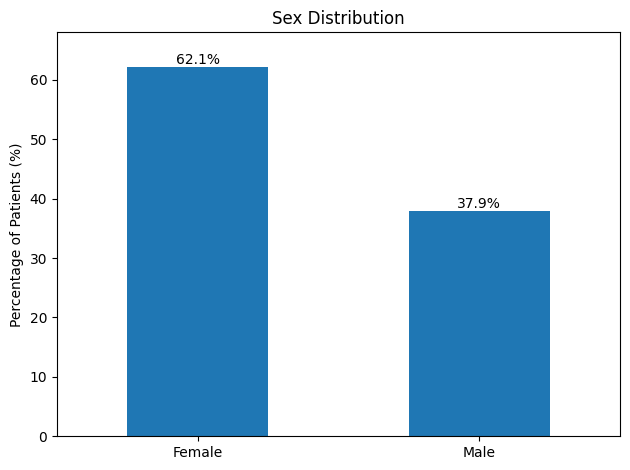

In [14]:
# visualize distribution
sex_distrib = df['sex'].value_counts(normalize=True) * 100
ax = sex_distrib.plot(
    kind='bar', 
    title='Sex Distribution',
    ylabel='Percentage of Patients (%)',
    xlabel='',
    ylim=(0, 68)

)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(np.arange(2),['Female','Male'], rotation=0)
plt.tight_layout()
plt.show()

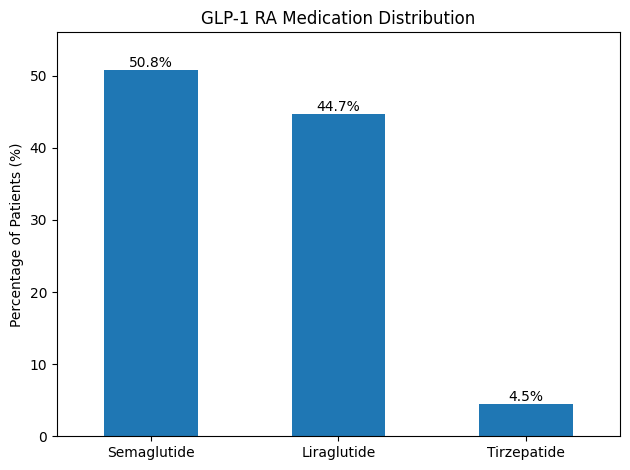

In [15]:
# visualize distribution
glp_distrib = df['glp_medication'].value_counts(normalize=True) * 100
ax = glp_distrib.plot(
    kind='bar', 
    title='GLP-1 RA Medication Distribution',
    ylabel='Percentage of Patients (%)',
    xlabel='',
    ylim=(0, 56)
)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(np.arange(3), ['Semaglutide','Liraglutide','Tirzepatide'], rotation=0)
plt.tight_layout()
plt.show()

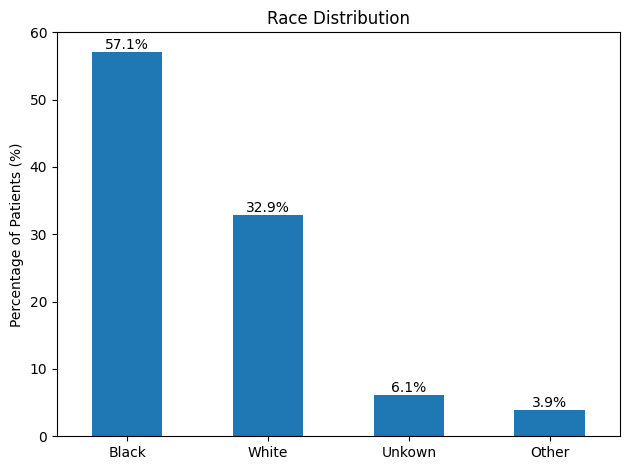

In [16]:
# visualize distribution
race_distrib = df['race'].value_counts(normalize=True) * 100
ax = race_distrib.plot(
    kind='bar', 
    title='Race Distribution',
    ylabel='Percentage of Patients (%)',
    xlabel='',
    ylim=(0, 60)
)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(np.arange(4), ['Black','White','Unkown','Other'], rotation=0)
plt.tight_layout()
plt.show()

- Asian and Multiracial patients did not make up a significant proportion of the dataset and were labeled as `other`

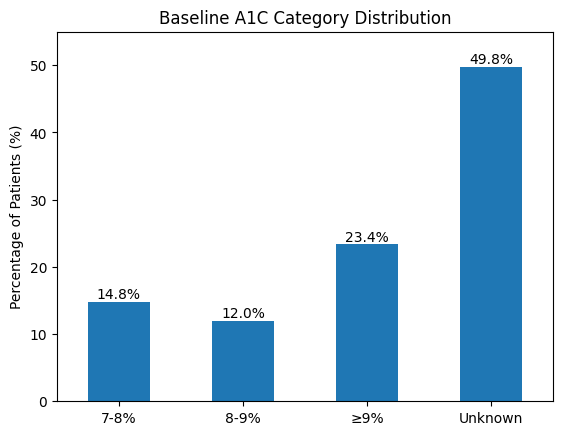

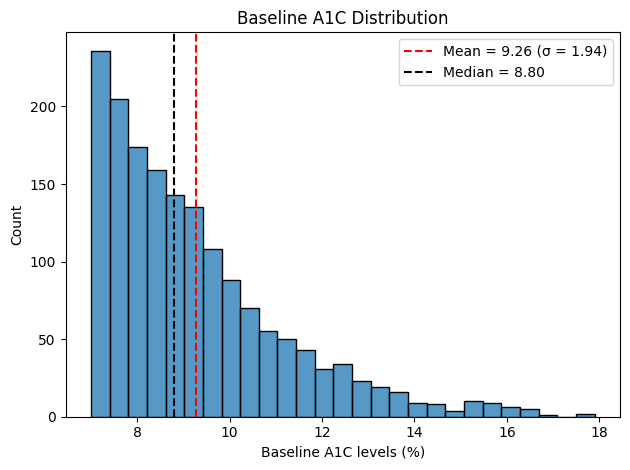

In [17]:
# visualize distribution of A1C categories
baseline_distrib = df['baseline_category'].value_counts(normalize=True).sort_index() * 100
ax = baseline_distrib.plot(
    kind='bar', 
    title='Baseline A1C Category Distribution', 
    ylabel= 'Percentage of Patients (%)',
    xlabel='',
    ylim=(0, 55),
)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(np.arange(4), ['7-8%','8-9%','≥9%','Unknown'], rotation=0)
plt.show()

# plot distribution of continuous baseline hba1c values
ax = sns.histplot(df['baseline_hba1c_result'], label='_nolegend_')

mu = np.mean(df['baseline_hba1c_result'])
mu_std = np.std(df['baseline_hba1c_result'])
median = np.nanmedian(df['baseline_hba1c_result'])

ax.axvline(mu, c='r', ls='--', label=f'Mean = {mu:.2f} (σ = {mu_std:.2f})')
ax.axvline(median, c='k', ls='--', label=f'Median = {median:.2f}')
ax.set_title(f'Baseline A1C Distribution')
ax.set_xlabel('Baseline A1C levels (%)')
plt.legend()
plt.tight_layout()
plt.show()

# drop continuous baseline hba1c result to reduce collinearity
df = df.drop(columns=['baseline_hba1c_result'])

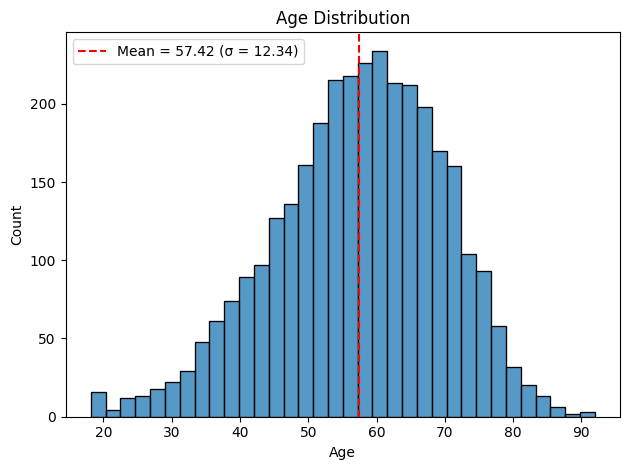

In [18]:
# plot distribution of continuous baseline hba1c values
ax = sns.histplot(df['age'], label='_nolegend_')
ax.axvline(np.mean(df['age']), color='r', linestyle='dashed')
ax.set_title(f'Age Distribution')
ax.set_xlabel('Age')
ax.legend([f'Mean = {np.mean(df['age']):.2f} (σ = {np.std(df['age']):.2f})'])
plt.tight_layout()
plt.show()

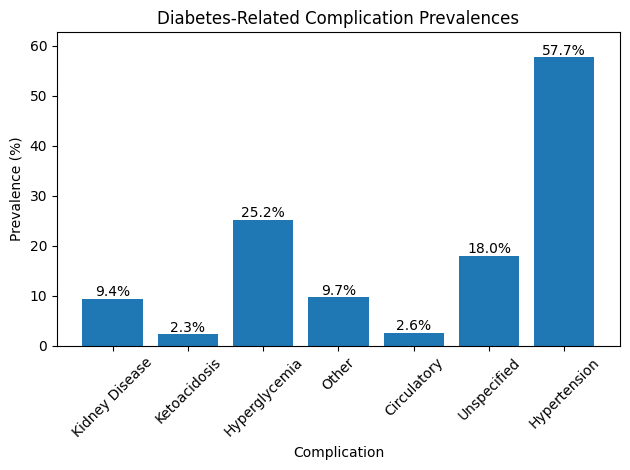

In [19]:
# CALCULATE COMPLICATIONS PREVALENCES

prevalances = []

complications_rename = [
    'Kidney Disease', 
    'Ketoacidosis', 
    'Hyperglycemia', 
    'Other', 
    'Circulatory', 
    'Unspecified', 
    'Hypertension'
]

for name in complications:
    prev = df[name].value_counts(normalize=True).sort_index() * 100
    prevalances.append(round(prev[1], 2))

plt.bar(complications_rename, prevalances)
plt.title('Diabetes-Related Complication Prevalences')
plt.xlabel('Complication')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=45)
plt.ylim(0, np.max(prevalances)+5)

for i, val in enumerate(prevalances):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

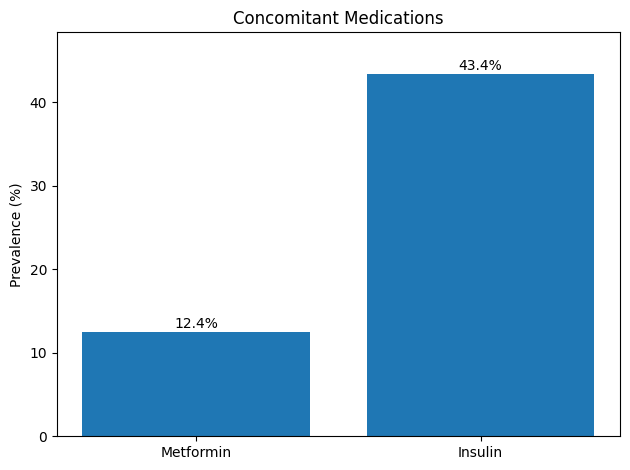

In [20]:
# CALCULATE CONCOMITANT MEDICATIONS PREVALENCES

medications = []

for name in concomitants:
    prev = df[name].value_counts(normalize=True).sort_index() * 100
    medications.append(round(prev[1],2))

plt.bar(['Metformin','Insulin'], medications)
plt.title('Concomitant Medications')
plt.xlabel('')
plt.ylabel('Prevalence (%)')
plt.xticks(rotation=0)
plt.ylim(0, np.max(medications)+5)

for i, val in enumerate(medications):
    plt.text(i, val + 0.5, f'{val:.1f}%', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

## Treatment Outcomes by Key Predictors

In [21]:
# DESCRIPTIVE STATISTICS

T1=TableOne(
    df.copy(),
    columns=df.columns.tolist(),
    categorical=[
        'sex',
        'race',
        'glp_medication',
        'has_kidney_disease',
        'has_ketoacidosis',
        'has_hyperglycemia',
        'has_other_specified',
        'has_circulatory',
        'has_unspecified',
        'metformin_use',
        'insulin_use',
        'has_hypertension',
        'baseline_category',
        #'age_category'
    ],
    row_percent=True,
    groupby='glycemic_control',
    pval=True,
    htest_name=True
)
print(T1.tabulate(tablefmt = "fancy_grid"))

╒════════════════════════════╤═════════════╤═══════════╤══════════════╤═════════════╤═════════════╤═══════════╤════════════════╕
│                            │             │ Missing   │ Overall      │ 0           │ 1           │ P-Value   │ Test           │
╞════════════════════════════╪═════════════╪═══════════╪══════════════╪═════════════╪═════════════╪═══════════╪════════════════╡
│ n                          │             │           │ 3272         │ 1955        │ 1317        │           │                │
├────────────────────────────┼─────────────┼───────────┼──────────────┼─────────────┼─────────────┼───────────┼────────────────┤
│ sex, n (%)                 │ female      │           │ 2032 (100.0) │ 1198 (59.0) │ 834 (41.0)  │ 0.251     │ Chi-squared    │
├────────────────────────────┼─────────────┼───────────┼──────────────┼─────────────┼─────────────┼───────────┼────────────────┤
│                            │ male        │           │ 1240 (100.0) │ 757 (61.0)  │ 483 (39.0) 

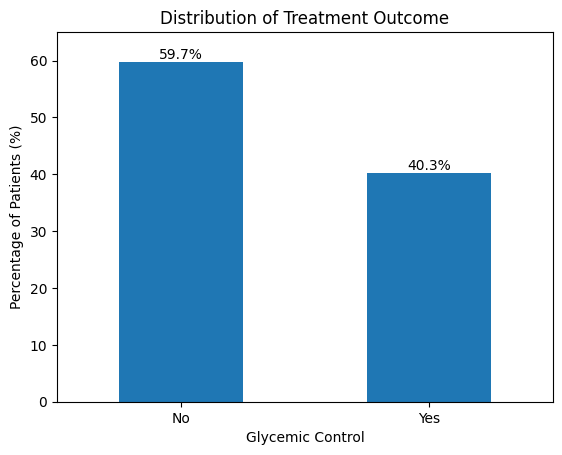

In [22]:
gly_control = df['glycemic_control'].value_counts(normalize=True).sort_index() * 100
ax = gly_control.plot(
    kind='bar',
    title='Distribution of Treatment Outcome',
    ylabel='Percentage of Patients (%)',
    xlabel='Glycemic Control',
    ylim=(0, 65)
)
ax.bar_label(ax.containers[0], fmt='%.1f%%')
plt.xticks(np.arange(2), ['No','Yes'], rotation=0)
plt.show()

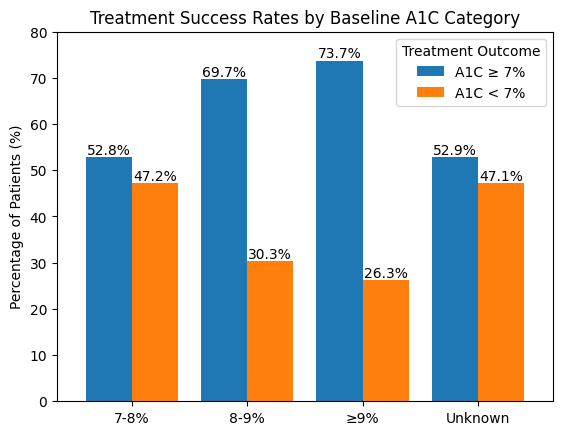

In [23]:
plot_outcome_crosstab(df, 'baseline_category', 'Treatment Success Rates by Baseline A1C Category', '', ['7-8%','8-9%','≥9%','Unknown'])

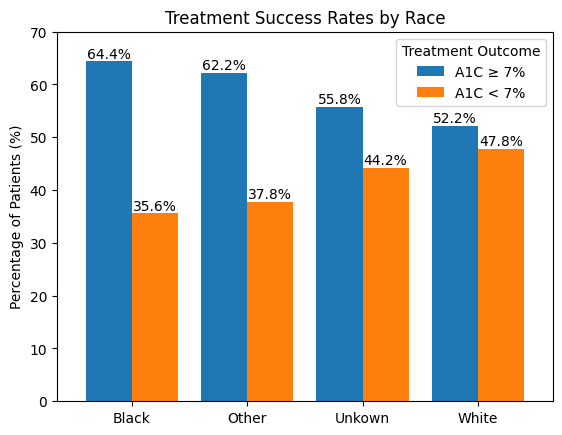

In [24]:
plot_outcome_crosstab(df, 'race', 'Treatment Success Rates by Race', '', ['Black','Other','Unkown','White'], ylim=(0, 70))

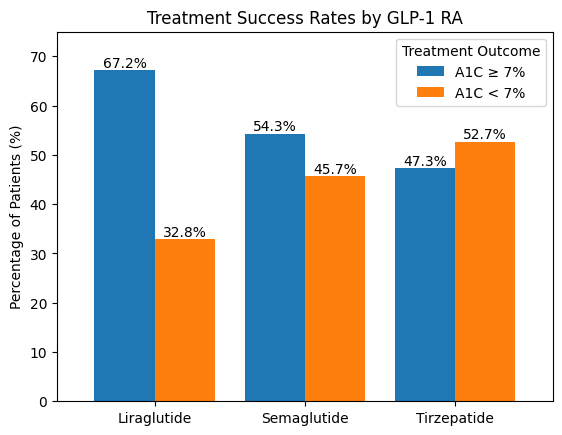

In [25]:
plot_outcome_crosstab(df, 'glp_medication', 'Treatment Success Rates by GLP-1 RA', '', ['Liraglutide','Semaglutide','Tirzepatide'], ylim=(0, 75))

# Classification Models

In [26]:
model_names = {
    'lr':'Logistic Regression',
    'dtc':'Decision Tree Classifier',
    'rfc':'Random Forest Classifier',
}

In [27]:
X = df.drop(columns=['glycemic_control'])
y = df['glycemic_control']

In [28]:
X.columns.tolist()

['sex',
 'race',
 'age',
 'glp_medication',
 'has_kidney_disease',
 'has_ketoacidosis',
 'has_hyperglycemia',
 'has_other_specified',
 'has_circulatory',
 'has_unspecified',
 'metformin_use',
 'insulin_use',
 'has_hypertension',
 'baseline_category']

# Model Development & Evaluation

In [29]:
# -------------------------
# 1) Preprocessing: Feature Encoding
# -------------------------

nominal_features = ['sex','race','glp_medication']
binary_numeric_features = ['has_kidney_disease','has_ketoacidosis','has_hyperglycemia','has_other_specified',
'has_circulatory','has_unspecified','metformin_use','insulin_use','has_hypertension'] # already 1/0 ints

preprocess = ColumnTransformer(
    transformers=[
        ('ordinal', OrdinalEncoder(categories=[['unknown','7-8%', '8-9%', '≥9%']]), ['baseline_category']),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False), nominal_features),
        ('binary', 'passthrough', binary_numeric_features),
        ('continuous', 'passthrough', ['age'])
    ],
    remainder='drop'
)

# -------------------------
# 2) Make Pipelines for Models
# -------------------------

models = {
    'lr': LogisticRegression(random_state=104, max_iter=5000),
    'dtc': DecisionTreeClassifier(random_state=104),
    'rfc': RandomForestClassifier(random_state=104),
}

pipelines = {} 

for name, model in models.items():
    pipelines[name] = Pipeline([("prep", preprocess), ("model", model)]) 

# -------------------------
# 3) Create Stratified Train, Test, and Validation Sets
# -------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=104, stratify=y # maintains class proportions of outcome (60/40) 
)

- stratify: [Hugo López-Fernández](https://medium.com/@hlfzeus/stratified-splitting-with-train-test-split-using-target-and-group-variables-part-1-f3dbe5ce84fd)

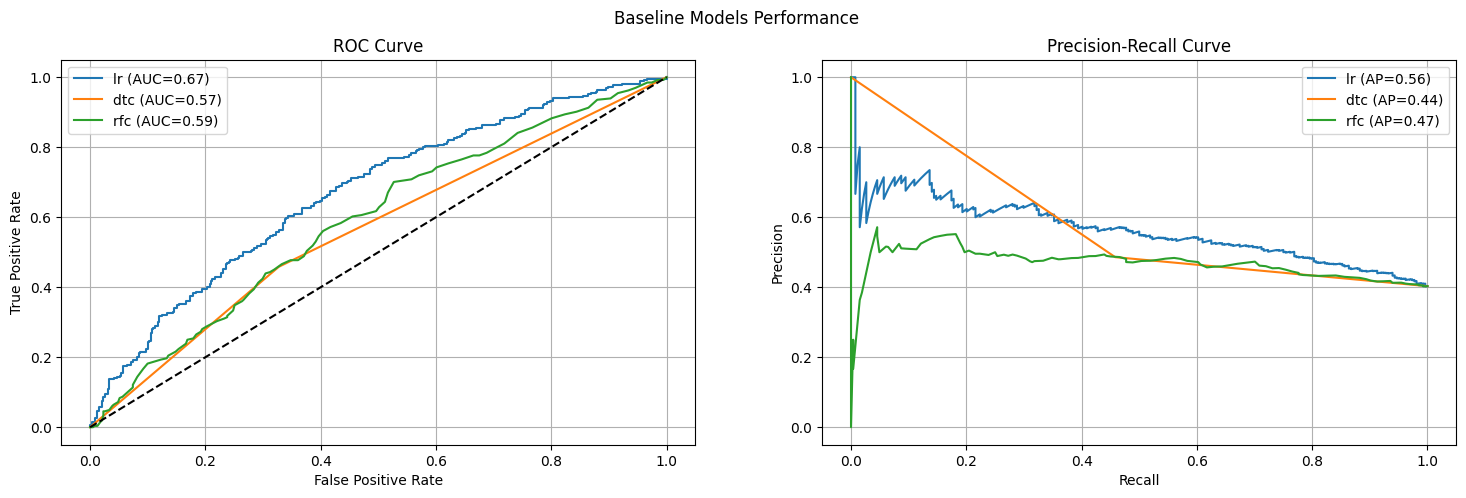

In [30]:
# -------------------------
# 4) Fit Models
# -------------------------

baseline_results = {}

f, ax = plt.subplots(1, 2, figsize=(18, 5))

f.suptitle('Baseline Models Performance')

for name, pipe in pipelines.items():
    # train model on data
    pipe.fit(X_train, y_train)

    # predict classification label
    y_pred = pipe.predict(X_test)

    # probabilities for Class 1
    y_proba = pipe.predict_proba(X_test)[:,1]

    # plot roc-curve
    plot_roc_curve(y_test, y_proba, ax=ax[0], label=name)

    # plot precision-recall curve
    plot_pr_curve(y_test, y_proba, ax=ax[1], label=name)

    # add to results dictionary
    baseline_results[name] = {
        #'pipe': pipe,
        'y_pred': y_pred, 
        'y_proba': y_proba
    }
ax[0].plot([0, 1], [0, 1], 'k--')
plt.show()

In [31]:
print_classification_metrics(baseline_results, y_test, model_names)


Logistic Regression
              precision    recall  f1-score   support

           0       0.66      0.83      0.73       391
           1       0.59      0.37      0.45       264

    accuracy                           0.64       655
   macro avg       0.62      0.60      0.59       655
weighted avg       0.63      0.64      0.62       655

ROC-AUC: 0.67
PR-AP: 0.56

Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.65      0.67      0.66       391
           1       0.49      0.46      0.47       264

    accuracy                           0.59       655
   macro avg       0.57      0.57      0.57       655
weighted avg       0.58      0.59      0.58       655

ROC-AUC: 0.57
PR-AP: 0.44

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.64      0.71      0.67       391
           1       0.49      0.41      0.45       264

    accuracy                           0.59       655
   

In [32]:
class_metrics_table(baseline_results, y_test, model_names)

,ROC-AUC,PR-AP,Accuracy,Precision,Recall,F1
Model,,,,,,
Logistic Regression,0.67,0.56,0.64,0.59,0.37,0.45
Decision Tree Classifier,0.57,0.44,0.59,0.49,0.46,0.47
Random Forest Classifier,0.59,0.47,0.59,0.49,0.41,0.45


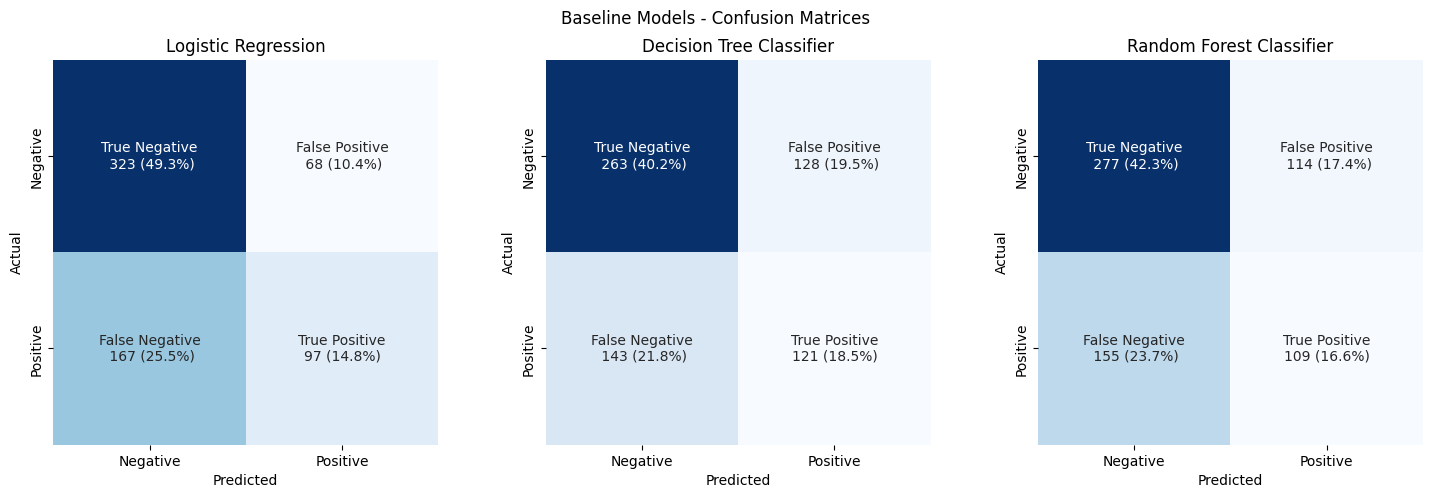

In [33]:
f, ax = plt.subplots(1, 3, figsize=(18, 5))
f.suptitle('Baseline Models - Confusion Matrices')

i = 0
for name, preds in baseline_results.items():
    plot_confmat(y_test, preds['y_pred'], model_names, ax=ax[i], name=name)
    i += 1

## Hyperparameter Tuning

In [34]:
# -------------------------
# 1) Stratified Cross-Validation
# -------------------------

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=104)

# -------------------------
# 3) Hyperparameters
# -------------------------

lr_hyperparamters = {
    'model__C': [0.001, 0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.0, 0.2, 0.5, 0.8, 1.0],
    'model__solver': ['saga'],
    'model__class_weight': ['balanced', None],
    'model__penalty': ['elasticnet']
}

dtc_hyperparameter = {
    'model__max_depth': [3, 5, None],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4],
    'model__class_weight': ['balanced', None]
}

rfc_hyperparamters = {
    'model__max_depth': [3, 5, None],
    'model__max_features': [0.1, 'sqrt', 'log2', 0.5, 1.0],
    'model__n_estimators': [25, 50, 75, 100],
    'model__min_samples_split': [5, 10],
    'model__class_weight': ['balanced', None]

}

gbc_hyperparameter = {
    'model__n_estimators': [25, 50, 75, 100],
    'model__learning_rate': [0.01, 0.1, 0.2],
    'model__max_depth': [3, 5, 7],
}

param_grid = {
    'lr': lr_hyperparamters,
    'dtc': dtc_hyperparameter,
    'rfc': rfc_hyperparamters,
    'gbc': gbc_hyperparameter
}

/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/deannakelly/code/glp-1-responders/.venv/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty'

MODEL: lr | BEST PARAMETERS: {'model__C': 0.1, 'model__class_weight': 'balanced', 'model__l1_ratio': 1.0, 'model__penalty': 'elasticnet', 'model__solver': 'saga'}
MODEL: dtc | BEST PARAMETERS: {'model__class_weight': 'balanced', 'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
MODEL: rfc | BEST PARAMETERS: {'model__class_weight': None, 'model__max_depth': 5, 'model__max_features': 'sqrt', 'model__min_samples_split': 5, 'model__n_estimators': 50}


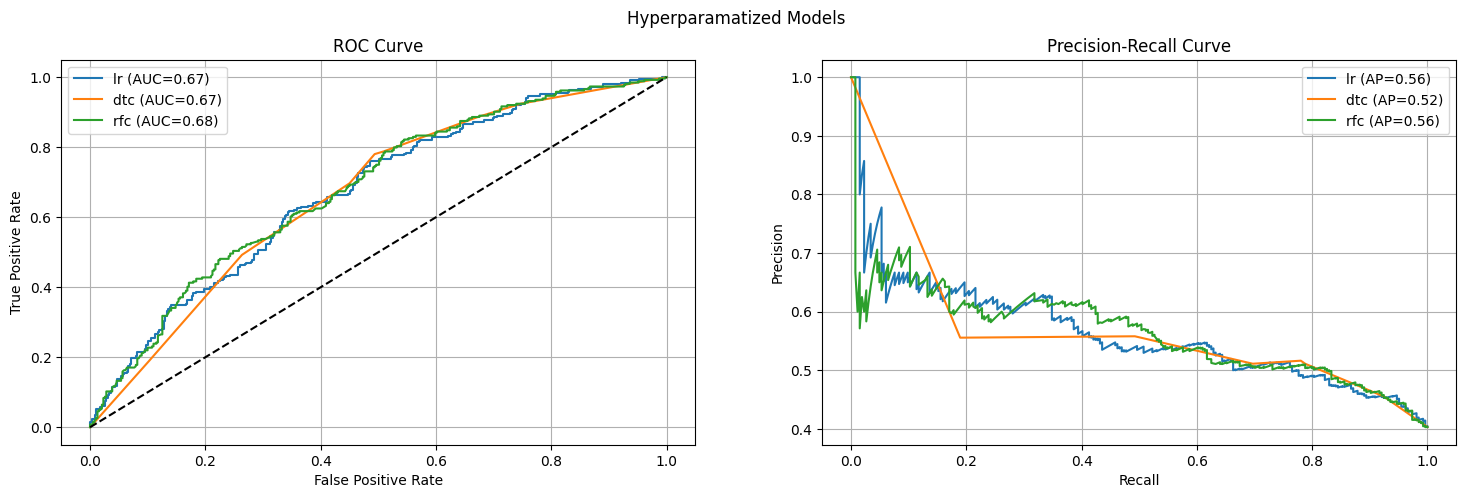

In [35]:
# -------------------------
# 3) Fit Models
# -------------------------

optimized_results = {}

f, ax = plt.subplots(1, 2, figsize=(18, 5))

f.suptitle('Hyperparamatized Models')

for name, pipe in pipelines.items():

    grid_search = GridSearchCV(pipe, param_grid[name], cv = cv, scoring='average_precision', n_jobs=-1)

    grid_search.fit(X_train, y_train)

    best_params = grid_search.best_params_

    optimized_pipe = grid_search.best_estimator_

    y_pred = optimized_pipe.predict(X_test)

    y_proba = optimized_pipe.predict_proba(X_test)[:,1]

    optimized_results[name] = {
        'pipe': optimized_pipe,
        'y_pred': y_pred,
        'y_proba': y_proba
    }

    # print results
    print(f'MODEL: {name} | BEST PARAMETERS: {best_params}')

    # plot roc-curve
    plot_roc_curve(y_test, y_proba, ax=ax[0], label=name)

    # plot precision-recall curve
    plot_pr_curve(y_test, y_proba, ax=ax[1], label=name)
ax[0].plot([0, 1], [0, 1], 'k--')
plt.show()

In [36]:
print_classification_metrics(optimized_results, y_test, model_names)


Logistic Regression
              precision    recall  f1-score   support

           0       0.71      0.59      0.64       391
           1       0.52      0.65      0.57       264

    accuracy                           0.61       655
   macro avg       0.61      0.62      0.61       655
weighted avg       0.63      0.61      0.62       655

ROC-AUC: 0.67
PR-AP: 0.56

Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.73      0.55      0.63       391
           1       0.51      0.70      0.59       264

    accuracy                           0.61       655
   macro avg       0.62      0.62      0.61       655
weighted avg       0.64      0.61      0.61       655

ROC-AUC: 0.67
PR-AP: 0.52

Random Forest Classifier
              precision    recall  f1-score   support

           0       0.63      0.89      0.74       391
           1       0.59      0.24      0.34       264

    accuracy                           0.63       655
   

In [37]:
class_metrics_table(optimized_results, y_test, model_names)

,ROC-AUC,PR-AP,Accuracy,Precision,Recall,F1
Model,,,,,,
Logistic Regression,0.67,0.56,0.61,0.52,0.65,0.57
Decision Tree Classifier,0.67,0.52,0.61,0.51,0.70,0.59
Random Forest Classifier,0.68,0.56,0.63,0.59,0.24,0.34


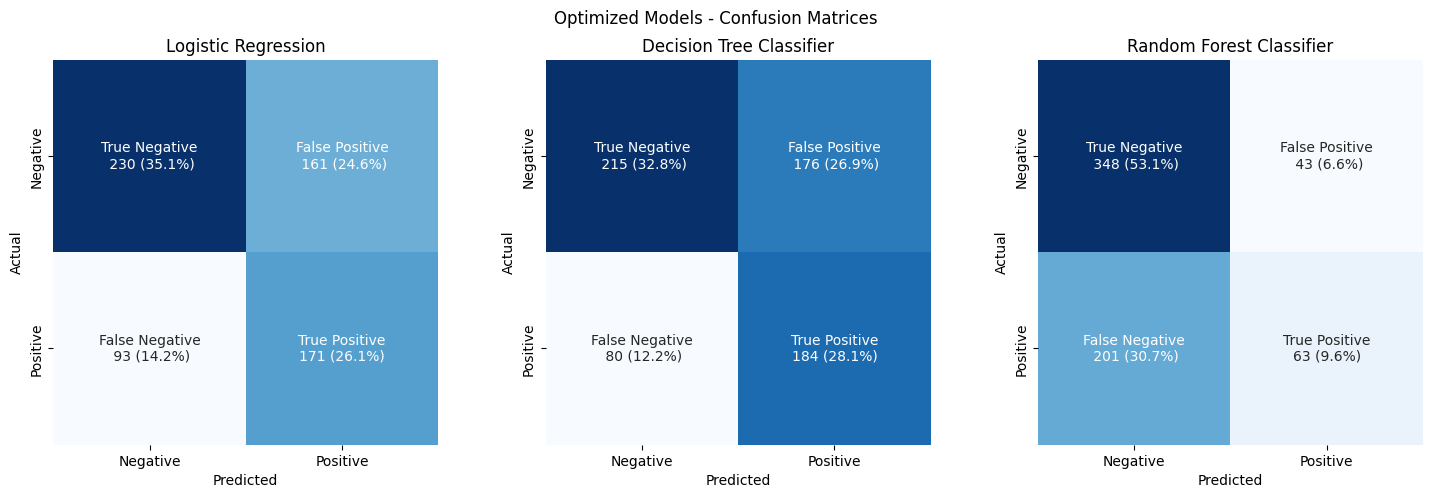

In [38]:
f, ax = plt.subplots(1, 3, figsize=(18, 5))
f.suptitle('Optimized Models - Confusion Matrices')

i = 0
for name, preds in optimized_results.items():
    plot_confmat(y_test, preds['y_pred'], model_names, ax=ax[i], name=name)
    i += 1

## Feature Importances

Which features are most predictive of treatment success?

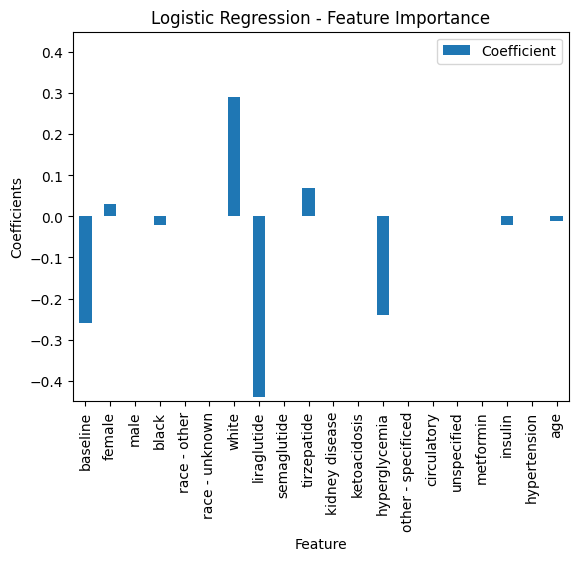

               Feature  Coefficient  Odds Ratio
6                white         0.29        1.34
9          tirzepatide         0.07        1.07
1               female         0.03        1.03
10      kidney disease         0.00        1.00
14         circulatory         0.00        1.00
2                 male         0.00        1.00
18        hypertension         0.00        1.00
4         race - other         0.00        1.00
5       race - unknown         0.00        1.00
16           metformin         0.00        1.00
8          semaglutide         0.00        1.00
11        ketoacidosis         0.00        1.00
15         unspecified         0.00        1.00
13  other - specificed         0.00        1.00
19                 age        -0.01        0.99
17             insulin        -0.02        0.98
3                black        -0.02        0.98
12       hyperglycemia        -0.24        0.78
0             baseline        -0.26        0.77
7          liraglutide        -0.44     

In [39]:
logreg = optimized_results['lr']['pipe']['model']

# feature importances for logistic regression
coefficients = logreg.coef_[0]
intercept = logreg.intercept_[0]

odds_ratios = np.exp(coefficients)
intercept_odds = np.exp(intercept)

# feature_names = preprocess.get_feature_names_out()
# print(feature_names)

feature_names = [
    'baseline',
    'female',
    'male',
    'black',
    'race - other',
    'race - unknown',
    'white',
    'liraglutide',
    'semaglutide',
    'tirzepatide',
    'kidney disease',
    'ketoacidosis',
    'hyperglycemia',
    'other - specificed',
    'circulatory',
    'unspecified',
    'metformin',
    'insulin',
    'hypertension',
    'age'
]

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': np.round(coefficients, 2),
    'Odds Ratio': np.round(odds_ratios, 2)
})

# plot feature importance

feature_importance.plot(kind='bar', x='Feature', y='Coefficient')
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.ylim(-0.45, 0.45)
plt.title('Logistic Regression - Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Coefficients')
plt.show()

print(feature_importance.sort_values(by='Coefficient', ascending=False))

- Patients with [feature] had OR−1 × 100% higher odds of achieving glycemic control, holding other variables constant.
- Patients with [feature] had (1−OR) × 100% lower odds of achieving glycemic control, holding other variables constant.

**Strongest Predictors**

1. **Baseline A1C**: Each one-category increase in baseline A1C level was associated with 23% lower odds (OR = 0.77) of achieving glycemic control 
2. **Race**: White patients had 34% higher odds of achieving glycemic control (OR = 1.34), while Black patients had 2% lower odds (OR = 0.98)
3. **GLP-1 RA Type**: Patients taking tirzepatide had 7% higher odds (OR = 1.07) of achieving glycemic control while patients taking liraglutide had 35% lower odds (OR = 0.65) 
4. **Hyperglycemia**: Patients with hyperglycemia had 21% lower odds (OR = 0.79) of achieving glycemic control 

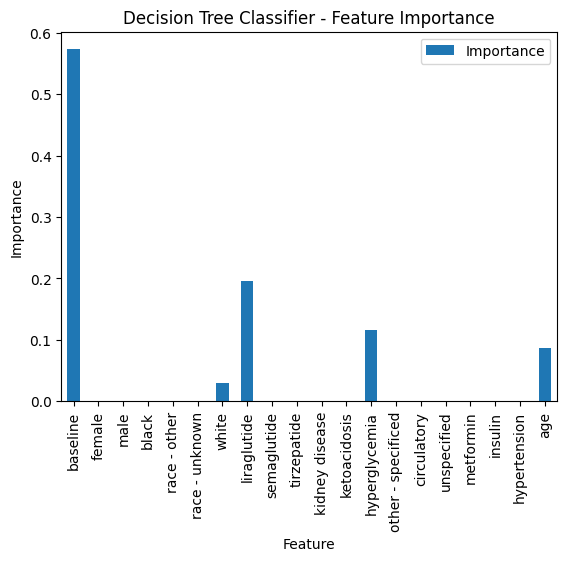

               Feature  Importance
0             baseline    0.573115
7          liraglutide    0.196412
12       hyperglycemia    0.115243
19                 age    0.086299
6                white    0.028930
4         race - other    0.000000
5       race - unknown    0.000000
3                black    0.000000
8          semaglutide    0.000000
9          tirzepatide    0.000000
1               female    0.000000
11        ketoacidosis    0.000000
2                 male    0.000000
13  other - specificed    0.000000
14         circulatory    0.000000
15         unspecified    0.000000
16           metformin    0.000000
17             insulin    0.000000
18        hypertension    0.000000
10      kidney disease    0.000000


In [40]:
dtree = optimized_results['dtc']['pipe']['model']

importance = dtree.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.title('Decision Tree Classifier - Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

print(feature_importance.sort_values(by='Importance', ascending=False))

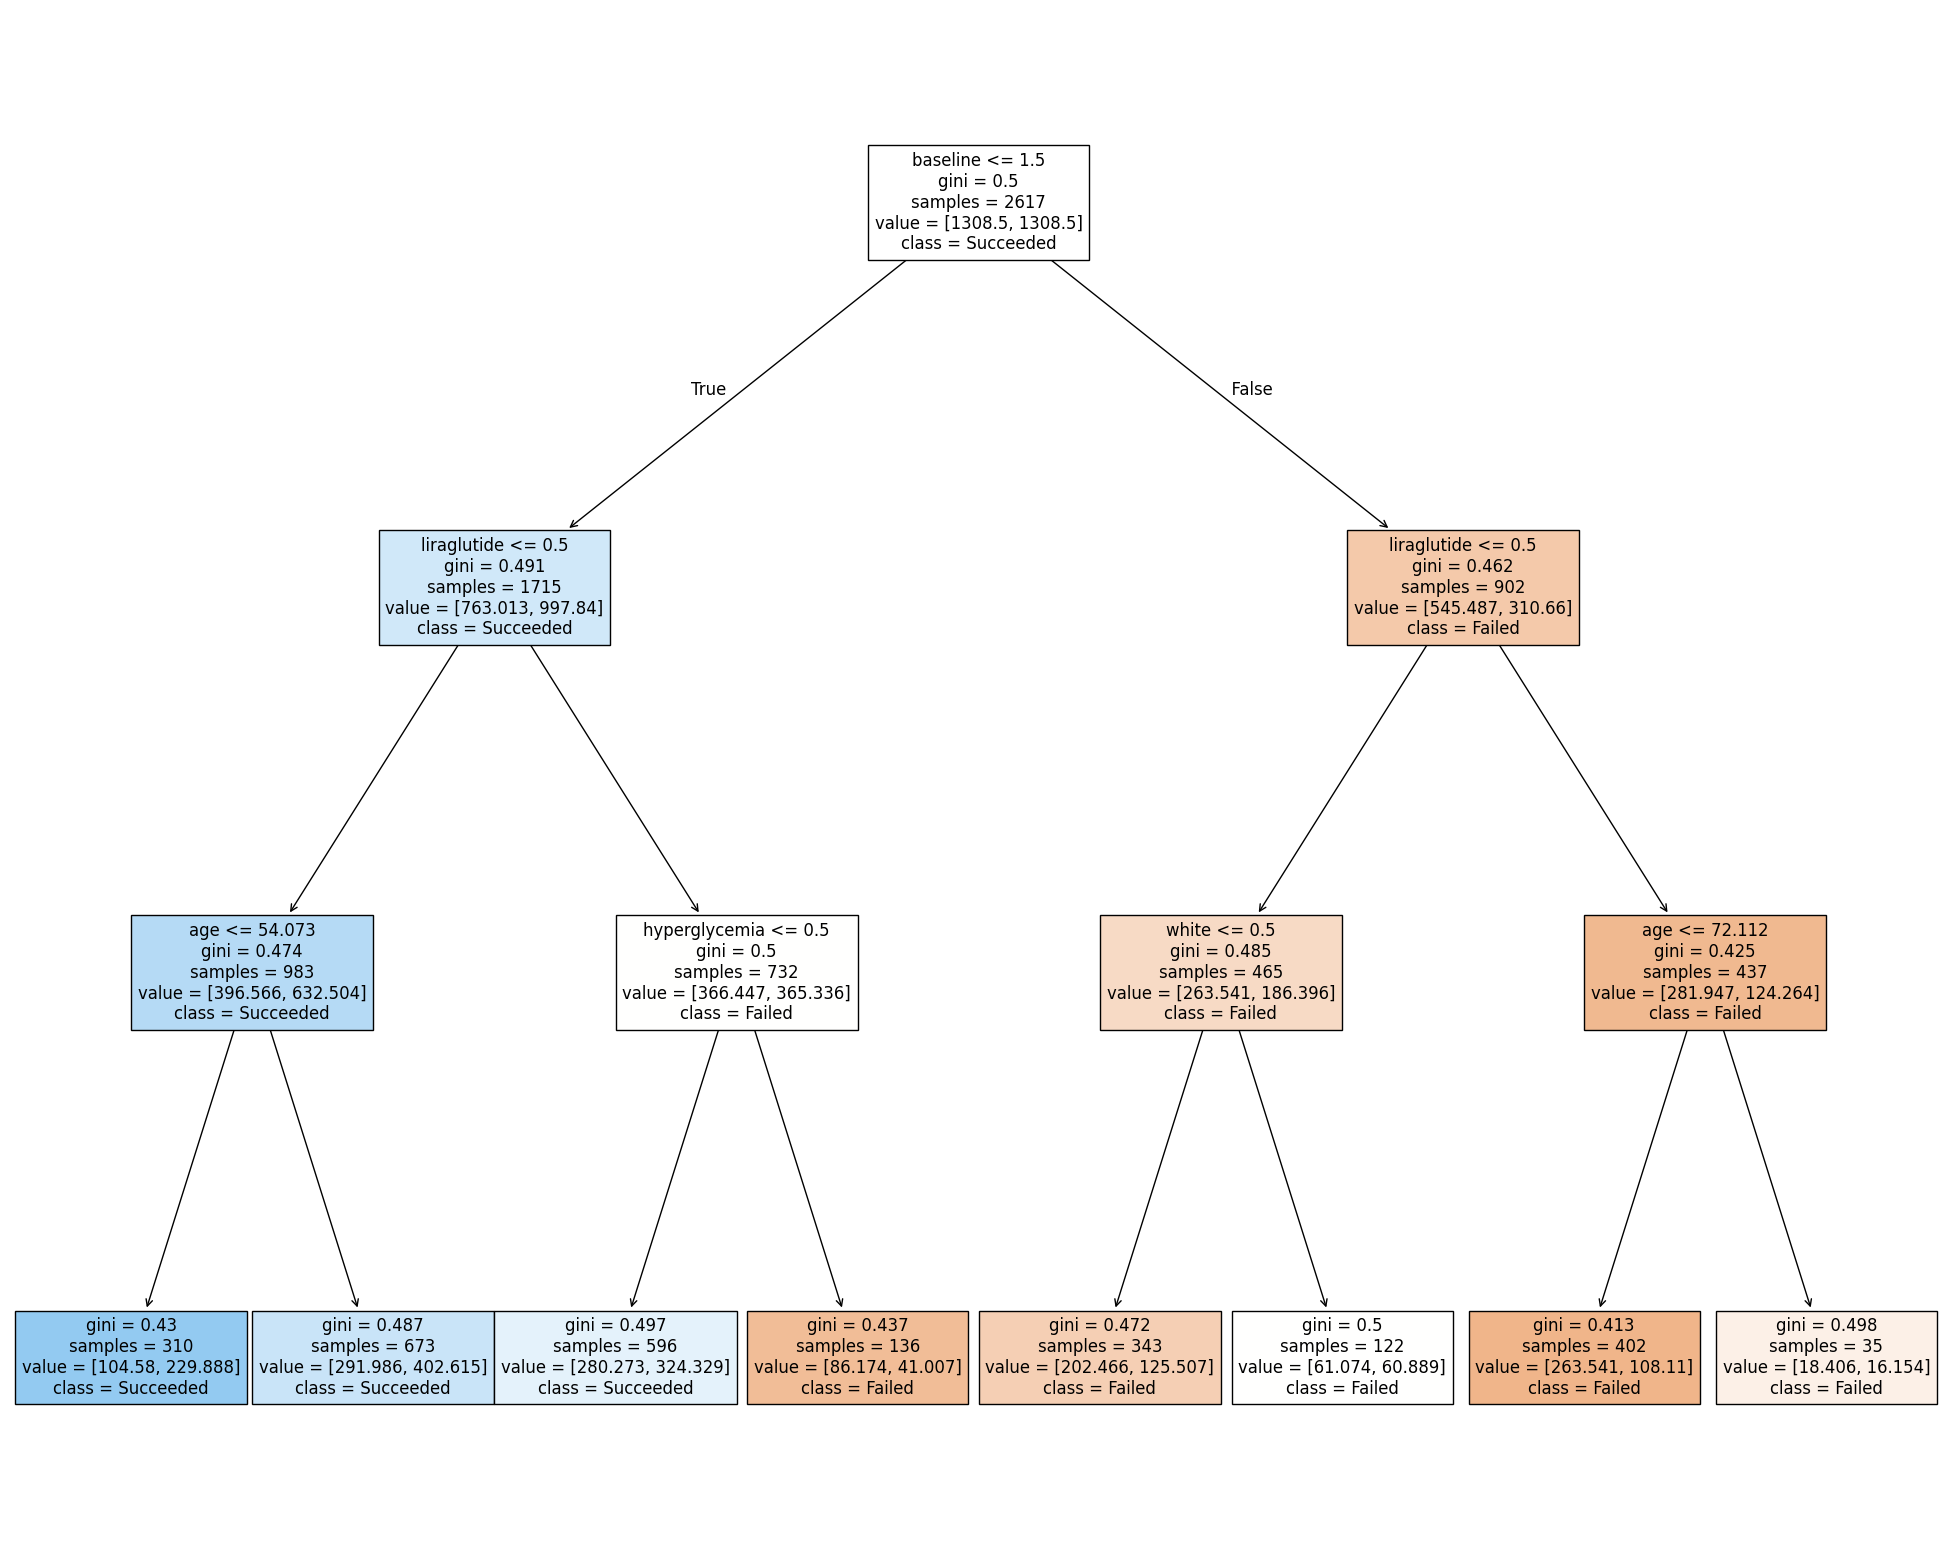

In [41]:
fig = plt.figure(figsize=(25,20))
_ = tree.plot_tree(dtree,
                   feature_names=feature_names,
                   class_names=['Failed','Succeeded'],
                   filled=True)

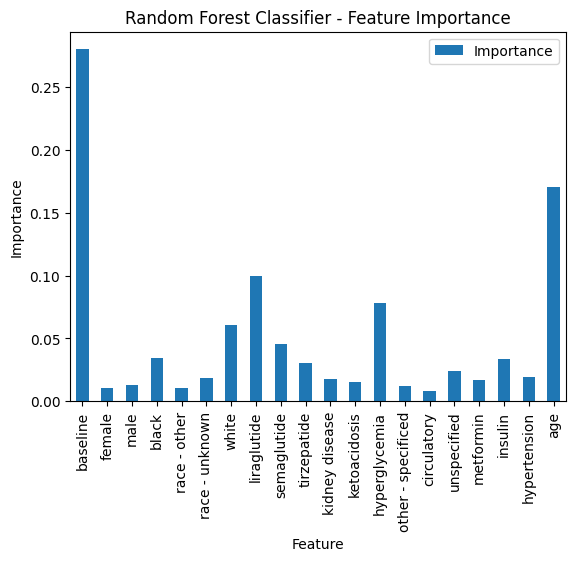

               Feature  Importance
0             baseline    0.280065
19                 age    0.170729
7          liraglutide    0.099698
12       hyperglycemia    0.078249
6                white    0.060680
8          semaglutide    0.045759
3                black    0.034693
17             insulin    0.033927
9          tirzepatide    0.030447
15         unspecified    0.023966
18        hypertension    0.019037
5       race - unknown    0.018837
10      kidney disease    0.017910
16           metformin    0.017245
11        ketoacidosis    0.014963
2                 male    0.013182
13  other - specificed    0.011987
4         race - other    0.010396
1               female    0.010379
14         circulatory    0.007851


In [42]:
ranforest = optimized_results['rfc']['pipe']['model']

importance = ranforest.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
})

feature_importance.plot(kind='bar', x='Feature', y='Importance')
plt.xticks(range(len(feature_names)), feature_names, rotation=90)
plt.title('Random Forest Classifier - Feature Importance')
plt.xlabel('Feature')
plt.ylabel('Importance')
plt.show()

print(feature_importance.sort_values(by='Importance', ascending=False))

# Patient Subgroup Analysis

In [43]:
subgroups = {
    'baseline 7-8%':
        (df['baseline_category']=='7-8%'),

    'unknown':
        (df['baseline_category']=='unknown'),

    # Race x Baseline 
    'White + Baseline 7-8%':
        (df['race']=='white') & (df['baseline_category']=='7-8%'),

    'white + Baseline 7-8% + T':
        (df['race']=='white') & (df['baseline_category']=='7-8%') & (df['glp_medication']=='liraglutide'),

    'White + Unknown Baseline':
        (df['race']=='white') & (df['baseline_category']=='unknown'),

    'Black + Unknown Baseline':
        (df['race']=='black') & (df['baseline_category']=='unknown'),

    # Race x Baseline x GLP-1 RA type

    ## Black Patients
    'Black + Baseline 8-9% + Tirzepatide': 
        (df['race'] == 'black') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'tirzepatide'),

    'Black + Baseline 8-9% + Semaglutide': 
        (df['race'] == 'black') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'semaglutide'),

    'Black + Baseline 8-9% + Liraglutide': 
        (df['race'] == 'black') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'liraglutide'),

    'Black + Baseline ≥9% + Tirzepatide': 
        (df['race'] == 'black') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'tirzepatide'),

    'Black + Baseline ≥9% + Semaglutide': 
        (df['race'] == 'black') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'semaglutide'),

    'Black + Baseline ≥9% + Liraglutide': 
        (df['race'] == 'black') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'liraglutide'),

    ## White Patients
    'White + Baseline 8-9% + Tirzepatide': 
        (df['race'] == 'white') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'tirzepatide'),

    'White + Baseline 8-9% + Semaglutide': 
        (df['race'] == 'white') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'semaglutide'),

    'White + Baseline 8-9% + Liraglutide': 
        (df['race'] == 'white') & (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'liraglutide'),

    'White + Baseline ≥9% + Tirzepatide': 
        (df['race'] == 'white') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'tirzepatide'),

    'White + Baseline ≥9% + Semaglutide': 
        (df['race'] == 'white') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'semaglutide'),

    'White + Baseline ≥9% + Liraglutide': 
        (df['race'] == 'white') & (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'liraglutide'),

    # Baseline A1C x GLP-1 RA type
    'Baseline ≥9% + Tirzepatide': 
        (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'tirzepatide'),

    'Baseline ≥9% + Semaglutide': 
        (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'semaglutide'),

    'Baseline ≥9% + Liraglutide': 
        (df['baseline_category'] == '≥9%') & (df['glp_medication'] == 'liraglutide'),

    'Baseline 8-9% + Semaglutide': 
        (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'semaglutide'),

    'Baseline 8-9% + Tirzepatide': 
        (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'tirzepatide'),

    'Baseline 8-9% + Liraglutide': 
        (df['baseline_category'] == '8-9%') & (df['glp_medication'] == 'liraglutide'),
}

results = []
remove = []

for name, mask in subgroups.items():
    subgroup = df[mask]
    n = len(subgroup)

    if n >= 20:  # only report subgroups with at least 20 patients
        success_count = (subgroup['glycemic_control'] == 1).sum()
        success_rate = (success_count / n) * 100

        results.append({
            'Subgroup': name,
            'N': n,
            'Success': success_count,
            'Success Rate': f'{success_rate:.1f}%',
            'Failure Rate': f'{100-success_rate:.1f}%'
        })
    else:
        remove.append((name, n))

# create DataFrame
subgroup_analysis = pd.DataFrame(results)

# sort by success rate
subgroup_analysis = subgroup_analysis.sort_values('Subgroup', ascending=False)

print(subgroup_analysis.to_string(index=False))
print('\n', remove)

                           Subgroup    N  Success Success Rate Failure Rate
          white + Baseline 7-8% + T   65       26        40.0%        60.0%
                            unknown 1629      768        47.1%        52.9%
                      baseline 7-8%  485      229        47.2%        52.8%
           White + Unknown Baseline  602      322        53.5%        46.5%
 White + Baseline ≥9% + Semaglutide   84       35        41.7%        58.3%
 White + Baseline ≥9% + Liraglutide   90       23        25.6%        74.4%
White + Baseline 8-9% + Semaglutide   68       31        45.6%        54.4%
White + Baseline 8-9% + Liraglutide   49       12        24.5%        75.5%
              White + Baseline 7-8%  175       87        49.7%        50.3%
           Black + Unknown Baseline  876      368        42.0%        58.0%
 Black + Baseline ≥9% + Tirzepatide   24        8        33.3%        66.7%
 Black + Baseline ≥9% + Semaglutide  216       59        27.3%        72.7%
 Black + Bas

**Race x Baseline A1C x GLP-1 RA Type**

- 42.9% of White patients on tirzepatide with a baseline A1C ≥ 9% (N=7) achieved glycemic control compared to 41.7% of White patients on semaglutide (N=84), and 25.6% patients on liraglutide (N=90) with with the same baseline A1C levels.
- 45.6% of White patients on semaglutide (N=68) with a baseline A1C within 8-9% achieved glycemic control compared to only 24.5% of White patients on liraglutide (N=49) within the same baseline A1C range.

- 33.3% of Black patients on tirzepatide (N=24) with a baseline A1C ≥ 9% achieved glycemic control compared to only 27.3% of Black patients on semaglutide (N=216) and 20.4% of Black patients on liraglutide (N=274) with the same baseline A1C levels.

- 31.4% of Black patients on semaglutide (N=102) with baseline 8-9% achieved glycemic control compared to 21.1% of Black patients on liraglutide (N=104) within the same baseline A1C range.

**Baseline A1C x GLP-1 RA Type**

- 34.3% of patients on tirzepatide with a baseline A1C ≥ 9% (N=35) achieved glycemic control compared to 31.1% of patients on semaglutide (n=344) and 21.2% of patients on liraglutide (N=386) with the same baseline A1C levels. 

- For patients with a baseline A1C within 8-9%, 36% of patients on semaglutide (N=200) achieved glycemic control compared to 22.2% of patients on liraglutide (N=178)


**High Severity (Baseline A1C ≥9%):**

| Medication | Overall Success Rate | Black Patients | White Patients |
|---|---|---|---|
| Tirzepatide | 34.3% (n=35) | 33.3% (n=24)* | -- |
| Semaglutide | 31.1% (n=344) | 27.3% (n=216) | 41.7% (n=84) |
| Liraglutide | 21.2% (n=386) | 20.4% (n=274) | 25.6% (n=90) |

*Small sample size; interpret with caution

**Moderate Severity (Baseline A1C 8-9%):**

| Medication | Overall Success Rate | Black Patients | White Patients |
|---|---|---|---|
| Tirzepatide | -- | -- | -- |
| Semaglutide | 36.0% (n=200) | 31.4% (n=102) | 45.6% (n=68) |
| Liraglutide | 22.5% (n=178) | 21.1% (n=109) | 24.5% (n=49) |

**Mild Severity (Baseline A1C 7-8%):**

| Patient Group | Success Rate |
|---|---|
| Overall | 47.2% (n=485) |
| White patients | 49.7% (n=175) |
| Black patients | 44.8% (n=259) |

**Unknown Baseline (Healthier Population):**

| Patient Group | Success Rate |
|---|---|
| Overall | 47.1% (n=1629) |
| Black patients | 53.5% (n=876) |
| White patients | 42.0% (n=602) |

### Key Findings

**1. Disease severity overshadows other factors.** Within the same medication and race, the success rates of patients with a baseline 8-9% were generally higher than patients with a baseline ≥9%

**2. Liraglutide consistently underperforms across all severity levels and racial groups.** Liraglutide shows 20-25% success rates compared to 30-45% for semaglutide in similar subgroups. There is 9-13% difference between the success rates semaglutide and liraglutide overall.

**3. Racial Disparities Persist Across All Medications.**. Even when prescribed the same medication at the same disease severity, Black patients achieve lower success rates:

*Baseline ≥9% + Semaglutide:*
- White: 41.7% vs Black: 27.3% (**14.4 pp disparity**)

*Baseline 8-9% + Semaglutide:*
- White: 45.6% vs Black: 31.4% (**14.2 pp disparity**)

*Baseline ≥9% + Liraglutide:*
- White: 25.6% vs Black: 20.4% (**5.2 pp disparity**)